# EEC Comparison Plots

This notebook reads the saved percentile-summary `pkl` files from two cards and produces the three comparison figures:

- SIDIS `A_{UT,EEC}^{\sin(\phi+\phi_S)}`
- `e^+e^-` `A_{UT,EEC}^{\cos(\phi+ar{\phi})}`
- unpolarized `EEC^{e^+e^-}`

The plotting style is adapted from the last plot in `ref.ipynb`, but without the ratio panels.


In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch


## Settings


In [2]:
card_name_w = "Default"
card_name_wo = "Default_noLQCD"

label_w = "wLQCD"
label_wo = "woLQCD"

plot_data_dir = Path("Plot_Data")
figure_dir = plot_data_dir / "Figures"
figure_dir.mkdir(parents=True, exist_ok=True)

sidis_plot_filename = "sidis_aut.pkl"
ee_aut_plot_filename = "ee_aut.pkl"
ee_eec_plot_filename = "ee_eec.pkl"

save_png = False
save_pdf = True

wLQCD_band_alpha = 0.9
woLQCD_band_alpha = 0.3
hatch_linewidth = 1.5
hatched_band_boundary_linewidth = hatch_linewidth

sidis_figsize = (24, 8)
ee_aut_figsize = (24, 8)
ee_eec_figsize = (12, 15)

aut_xlim = (1.0, 45.0)
ee_eec_xlim = (1.0, 45.0)
shared_chi_xticks = [10, 20, 30, 40]
ee_eec_y_scale = 389.4e3
ee_eec_ylabel = r"$\mathrm{EEC}\;(\mathrm{nb})$"
ee_eec_ylabel_x = 0.105
ee_eec_scale_note = ""
ee_eec_scale_note_x_frac = 0.93
ee_eec_scale_note_gap_frac = 0.04

sidis_panel_ylims = {
    0.01: (0.0, 0.008),
    0.10: (0.0, 0.08),
    0.30: (0.0, 0.23),
}
sidis_panel_yticks = {
    0.01: [0.001, 0.003, 0.005, 0.007],
    0.10: [0.01, 0.03, 0.05, 0.07],
    0.30: [0.05, 0.1, 0.15, 0.2],
}

ee_aut_panel_ylims = {
    1.00: (0.0, 0.0225),
    15.0: (0.0, 0.027),
    30.0: (0.0, 0.09),
}
ee_aut_panel_yticks = {
    1.00: [0.005, 0.01, 0.015, 0.02],
    15.0: [0.006, 0.012, 0.018, 0.024],
    30.0: [0.02, 0.04, 0.06, 0.08],
}

ee_eec_panel_ylims = {
    3.65: (0.0, 1.0),
    10.58: (0.0, 1.0),
}
ee_eec_panel_yticks = {
    3.65: [0.3, 0.6, 0.9],
    10.58: [0.3, 0.6, 0.9],
}


## Load Plot Data


In [3]:
def _load_plot_payload(card_name, filename):
    path = plot_data_dir / card_name / filename
    if not path.exists():
        raise FileNotFoundError(f"Missing plot data file: {path}")
    with path.open("rb") as f:
        payload = pickle.load(f)
    return payload, path


def _describe_payload(name, payload, path):
    print(f"{name}: {path}")
    print(f"  process={payload['process']}, scan={payload['scan_label']}, replicas={len(payload['replica_ids'])}, coeffs={len(payload['coeff_grid'])}")


sidis_w, sidis_w_path = _load_plot_payload(card_name_w, sidis_plot_filename)
sidis_wo, sidis_wo_path = _load_plot_payload(card_name_wo, sidis_plot_filename)

ee_aut_w, ee_aut_w_path = _load_plot_payload(card_name_w, ee_aut_plot_filename)
ee_aut_wo, ee_aut_wo_path = _load_plot_payload(card_name_wo, ee_aut_plot_filename)

ee_eec_w, ee_eec_w_path = _load_plot_payload(card_name_w, ee_eec_plot_filename)
ee_eec_wo, ee_eec_wo_path = _load_plot_payload(card_name_wo, ee_eec_plot_filename)

_describe_payload("SIDIS", sidis_w, sidis_w_path)
_describe_payload("SIDIS", sidis_wo, sidis_wo_path)
_describe_payload("EE AUT", ee_aut_w, ee_aut_w_path)
_describe_payload("EE AUT", ee_aut_wo, ee_aut_wo_path)
_describe_payload("EE EEC", ee_eec_w, ee_eec_w_path)
_describe_payload("EE EEC", ee_eec_wo, ee_eec_wo_path)


SIDIS: Plot_Data/Default/sidis_aut.pkl
  process=SIDIS_AUT, scan=a_b_uniform_area_100, replicas=100, coeffs=100
SIDIS: Plot_Data/Default_noLQCD/sidis_aut.pkl
  process=SIDIS_AUT, scan=a_b_uniform_area_100, replicas=100, coeffs=100
EE AUT: Plot_Data/Default/ee_aut.pkl
  process=EE_AUT, scan=a_b_uniform_area_100, replicas=100, coeffs=100
EE AUT: Plot_Data/Default_noLQCD/ee_aut.pkl
  process=EE_AUT, scan=a_b_uniform_area_100, replicas=100, coeffs=100
EE EEC: Plot_Data/Default/ee_eec.pkl
  process=EE_EEC, scan=a_b_uniform_area_100, replicas=100, coeffs=100
EE EEC: Plot_Data/Default_noLQCD/ee_eec.pkl
  process=EE_EEC, scan=a_b_uniform_area_100, replicas=100, coeffs=100


## Plotting Helpers


In [4]:
sizeOfFont = 18
sizeOfTick = 16
lineWidth = 0.8
props = dict(boxstyle="round", facecolor="white", alpha=0)

blue = (87 / 255, 144 / 255, 252 / 255)
orange = (248 / 255, 156 / 255, 32 / 255)
red = (228 / 255, 37 / 255, 54 / 255)
purple1 = (150 / 255, 74 / 255, 139 / 255)
gray = (156 / 255, 156 / 255, 156 / 255)
purple2 = (122 / 255, 33 / 255, 221 / 255)

color_cycle = [blue, red, orange, purple1, gray, purple2, "black"]
branch_alpha = {label_w: wLQCD_band_alpha, label_wo: woLQCD_band_alpha}
branch_hatch = {label_w: "\\", label_wo: None}

mpl.rcParams["hatch.linewidth"] = hatch_linewidth


def _style_axis(ax):
    ax.minorticks_on()
    ax.tick_params(axis="both", direction="in", length=5, labelsize=sizeOfTick, top=True, right=True)
    ax.tick_params(axis="both", which="minor", direction="in", length=2.5, labelsize=sizeOfTick, top=True, right=True)
    ax.grid(False)


def _branch_handles():
    return [
        Patch(facecolor="none", edgecolor="black", hatch=branch_hatch[label_w], linewidth=hatched_band_boundary_linewidth, label=label_w),
        Patch(facecolor="0.55", edgecolor="none", alpha=0.30, label=label_wo),
    ]


def _q_handles(q_values, colors):
    return [
        Patch(facecolor=color, edgecolor=color, alpha=0.25, label=rf"$Q={float(Q):g}\,\mathrm{{GeV}}$")
        for Q, color in zip(q_values, colors)
    ]


def _save_figure(fig, stem):
    saved = []
    if save_png:
        png_path = figure_dir / f"{stem}.png"
        fig.savefig(png_path, dpi=200, bbox_inches="tight")
        saved.append(png_path)
    if save_pdf:
        pdf_path = figure_dir / f"{stem}.pdf"
        fig.savefig(pdf_path, bbox_inches="tight")
        saved.append(pdf_path)
    for path in saved:
        print(f"saved: {path}")


def _assert_same_scan(payload_a, payload_b, *, label):
    if payload_a["scan_label"] != payload_b["scan_label"]:
        raise ValueError(f"{label}: scan label mismatch: {payload_a['scan_label']} vs {payload_b['scan_label']}")
    if np.asarray(payload_a["coeff_grid"]).shape != np.asarray(payload_b["coeff_grid"]).shape:
        raise ValueError(f"{label}: coefficient-grid shape mismatch")


def _assert_same_chi(entry_a, entry_b, *, label):
    chi_a = np.asarray(entry_a["chi_deg"], dtype=float)
    chi_b = np.asarray(entry_b["chi_deg"], dtype=float)
    if chi_a.shape != chi_b.shape or not np.allclose(chi_a, chi_b):
        raise ValueError(f"{label}: chi grid mismatch")
    return chi_a


def _w_hatch_for_q(q, q_values):
    if q_values is None:
        return branch_hatch[label_w]
    q_min = min(float(value) for value in q_values)
    return "/" if np.isclose(float(q), q_min) else branch_hatch[label_w]


def _fill_band(ax, chi_deg, lower, upper, color, *, branch_label, zorder=1, hatch_override=None):
    hatch = hatch_override if hatch_override is not None else branch_hatch[branch_label]
    if hatch:
        kwargs = dict(facecolor="none", edgecolor=color, hatch=hatch, linewidth=hatched_band_boundary_linewidth, alpha=0.72, zorder=zorder)
    else:
        kwargs = dict(facecolor=color, edgecolor="none", linewidth=0.0, alpha=branch_alpha[branch_label], zorder=zorder)
    ax.fill_between(chi_deg, lower, upper, **kwargs)


def _add_pair(ax, chi_deg, entry_w, entry_wo, color, *, q=None, q_values=None):
    lower_w = np.asarray(entry_w["lower_68"], dtype=float)
    upper_w = np.asarray(entry_w["upper_68"], dtype=float)
    lower_wo = np.asarray(entry_wo["lower_68"], dtype=float)
    upper_wo = np.asarray(entry_wo["upper_68"], dtype=float)

    _fill_band(ax, chi_deg, lower_wo, upper_wo, color, branch_label=label_wo, zorder=1)
    _fill_band(ax, chi_deg, lower_w, upper_w, color, branch_label=label_w, zorder=2, hatch_override=_w_hatch_for_q(q, q_values))

    return [lower_w, upper_w, lower_wo, upper_wo]


def _nice_zero_based_ticks(ymax, max_ticks=4):
    if np.isclose(ymax, 0.0):
        return np.array([0.0, 0.05])

    raw_step = ymax / max(max_ticks - 1, 1)
    exponent = np.floor(np.log10(raw_step))
    scale = 10 ** exponent

    for mult in (1.0, 1.5, 2.0, 2.5, 5.0, 10.0):
        step = mult * scale
        tick_count = int(np.ceil(ymax / step)) + 1
        if tick_count <= max_ticks:
            top = step * (tick_count - 1)
            return np.linspace(0.0, top, tick_count)

    step = 10.0 * scale
    tick_count = int(np.ceil(ymax / step)) + 1
    top = step * (tick_count - 1)
    return np.linspace(0.0, top, tick_count)


def _set_panel_ylim(ax, arrays, manual_ylim=None, manual_yticks=None):
    if manual_ylim is not None:
        ax.set_ylim(*manual_ylim)
        if manual_yticks is not None:
            ax.set_yticks(manual_yticks)
        return

    if manual_yticks is not None:
        ax.set_ylim(float(manual_yticks[0]), float(manual_yticks[-1]))
        ax.set_yticks(manual_yticks)
        return

    ymax = float(np.nanmax([np.nanmax(np.asarray(arr, dtype=float)) for arr in arrays]))
    ticks = _nice_zero_based_ticks(ymax, max_ticks=4)
    ax.set_ylim(0.0, float(ticks[-1]))
    ax.set_yticks(ticks)


## SIDIS Comparison


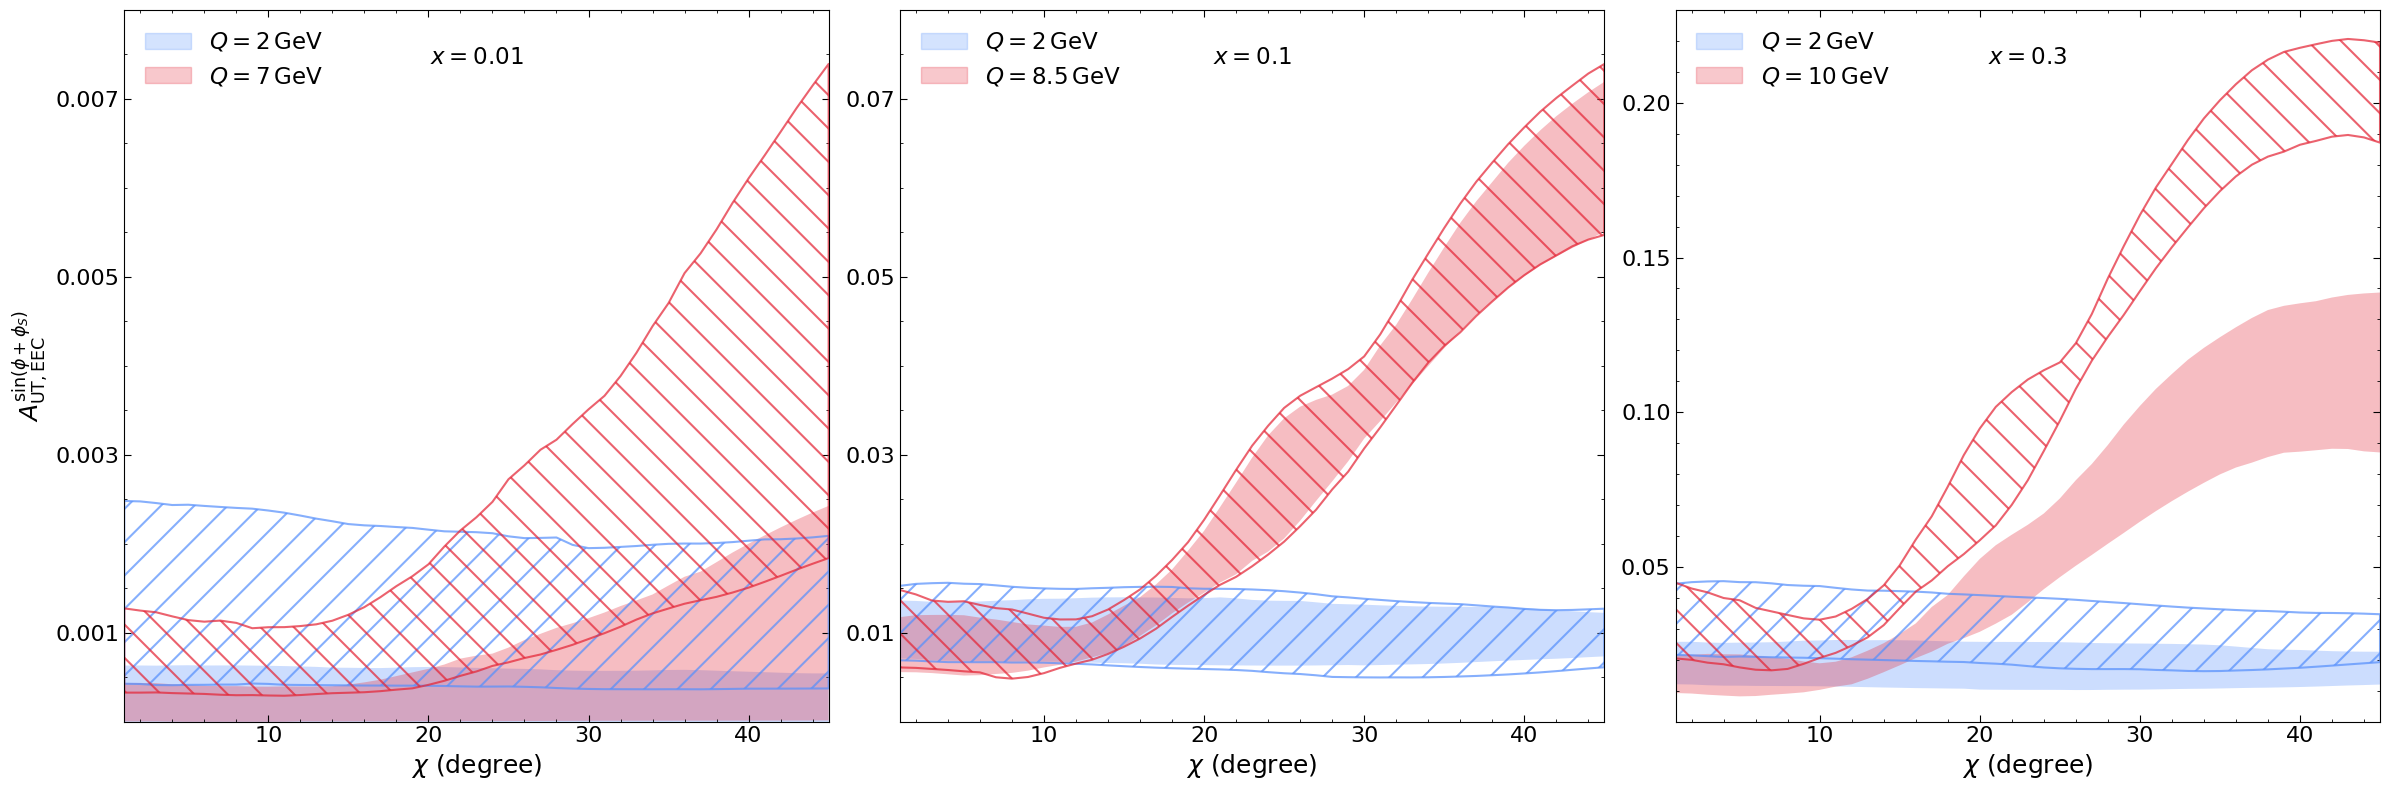

saved: Plot_Data/Figures/sidis_aut_compare.pdf


In [5]:
_assert_same_scan(sidis_w, sidis_wo, label="SIDIS")

x_values = [float(x) for x in sidis_w["x_values"]]
fig, axes = plt.subplots(1, len(x_values), figsize=sidis_figsize, sharex=True, sharey=False)
axes = np.atleast_1d(axes)

for ifig, (ax, x) in enumerate(zip(axes, x_values)):
    q_values = [float(Q) for Q in sidis_w["x_to_q"][x]]
    colors = color_cycle[:len(q_values)]
    panel_bounds = []

    for color, Q in zip(colors, q_values):
        key = (float(x), float(Q))
        entry_w = sidis_w["by_kinematics"][key]
        entry_wo = sidis_wo["by_kinematics"][key]
        chi_deg = _assert_same_chi(entry_w, entry_wo, label=f"SIDIS x={x:g}, Q={Q:g}")
        panel_bounds.extend(_add_pair(ax, chi_deg, entry_w, entry_wo, color, q=Q, q_values=q_values))

    panel_key = round(float(x), 2)
    _style_axis(ax)
    ax.set_xlim(*aut_xlim)
    ax.set_xticks(shared_chi_xticks)
    ax.set_xlabel(r"$\chi\ (\mathrm{degree})$", fontsize=sizeOfFont)
    ax.text(0.5, 0.95, rf"$x = {x:g}$", transform=ax.transAxes, fontsize=0.92 * sizeOfFont, verticalalignment="top", horizontalalignment="center", bbox=props)
    _set_panel_ylim(ax, panel_bounds, manual_ylim=sidis_panel_ylims.get(panel_key), manual_yticks=sidis_panel_yticks.get(panel_key))

    ax.legend(handles=_q_handles(q_values, colors), frameon=False, fontsize=0.92 * sizeOfFont, loc="upper left")

axes[0].set_ylabel(r"$A_{\mathrm{UT,EEC}}^{\sin(\phi+\phi_S)}$", fontsize=sizeOfFont)
fig.tight_layout(w_pad=1.2)
plt.show()
_save_figure(fig, "sidis_aut_compare")


## `e^+e^-` AUT Comparison


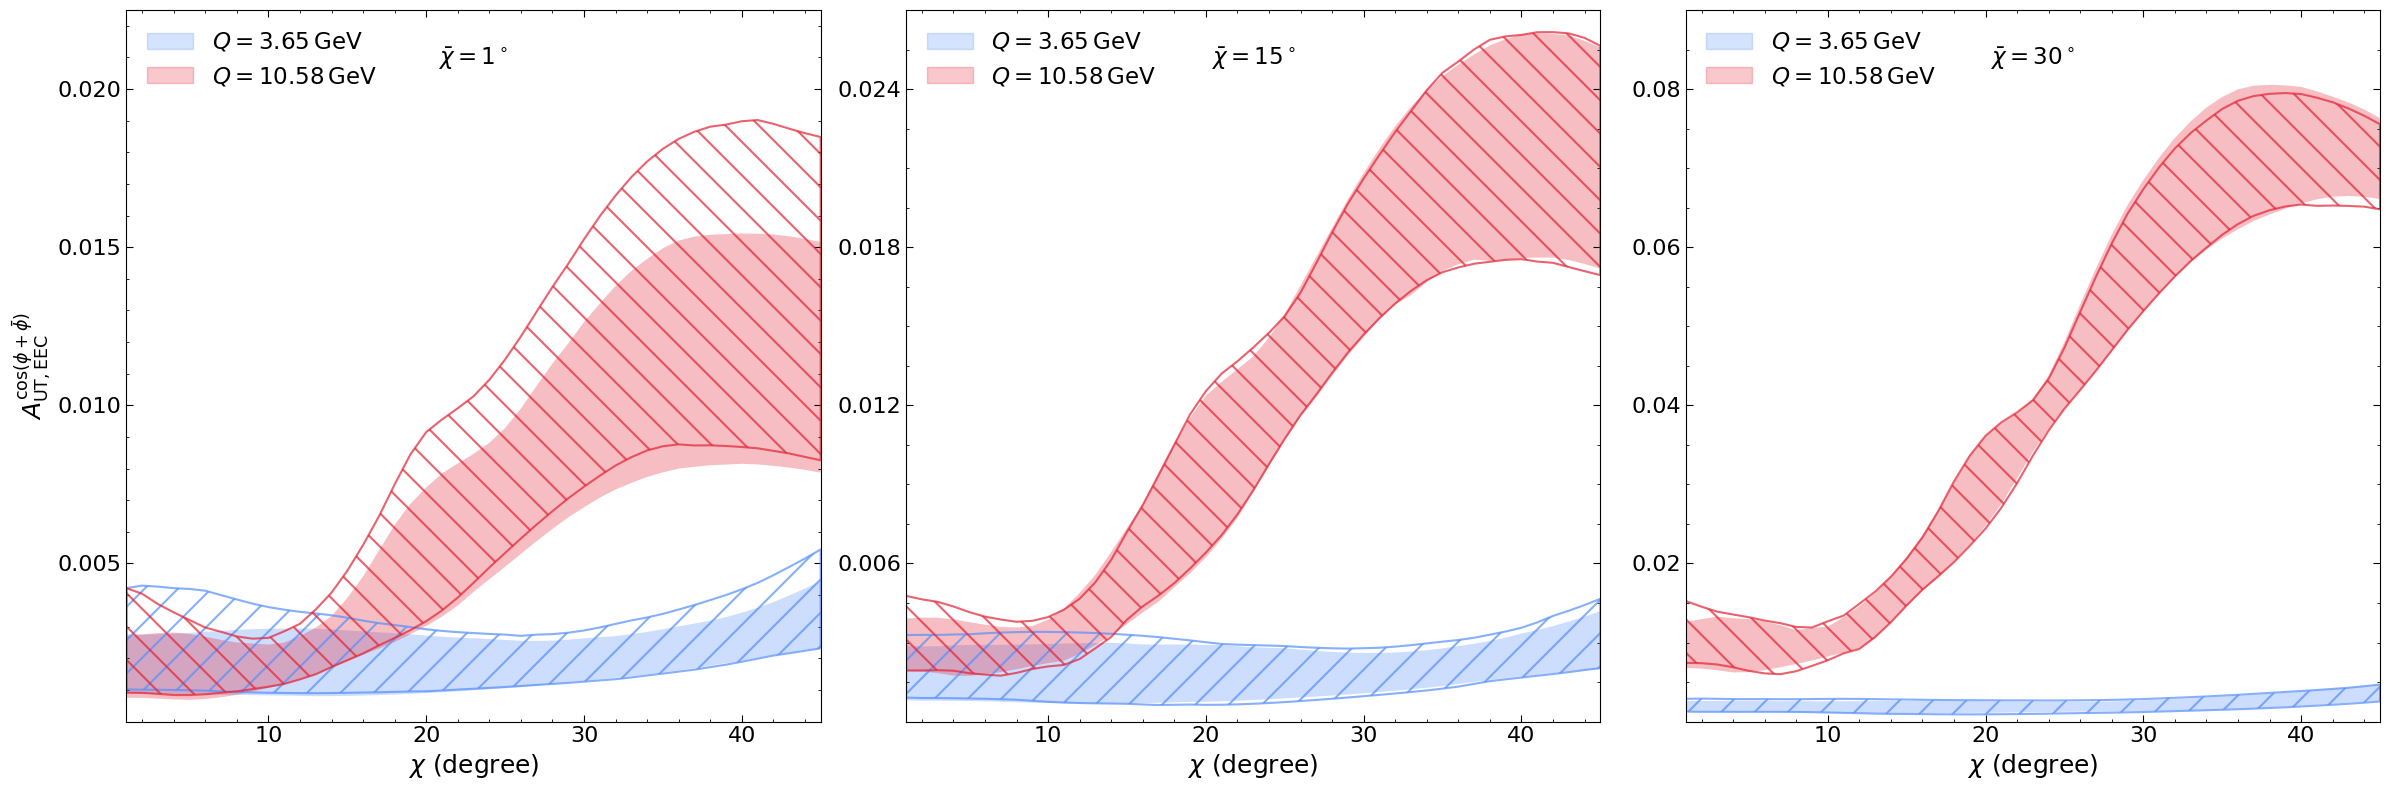

saved: Plot_Data/Figures/ee_aut_compare.pdf


In [6]:
_assert_same_scan(ee_aut_w, ee_aut_wo, label="EE AUT")

chibar_values = [float(value) for value in ee_aut_w["chibar_deg_list"]]
q_values = [float(value) for value in ee_aut_w["Q_list"]]
colors = color_cycle[:len(q_values)]

fig, axes = plt.subplots(1, len(chibar_values), figsize=ee_aut_figsize, sharex=True, sharey=False)
axes = np.atleast_1d(axes)

for ifig, (ax, chibar_deg) in enumerate(zip(axes, chibar_values)):
    panel_bounds = []

    for color, Q in zip(colors, q_values):
        key = (float(chibar_deg), float(Q))
        entry_w = ee_aut_w["by_kinematics"][key]
        entry_wo = ee_aut_wo["by_kinematics"][key]
        chi_deg = _assert_same_chi(entry_w, entry_wo, label=f"EE AUT chibar={chibar_deg:g}, Q={Q:g}")
        panel_bounds.extend(_add_pair(ax, chi_deg, entry_w, entry_wo, color, q=Q, q_values=q_values))

    panel_key = round(float(chibar_deg), 2)
    _style_axis(ax)
    ax.set_xlim(*aut_xlim)
    ax.set_xticks(shared_chi_xticks)
    ax.set_xlabel(r"$\chi\ (\mathrm{degree})$", fontsize=sizeOfFont)
    ax.text(0.5, 0.95, rf"$\bar{{\chi}} = {chibar_deg:g}^\circ$", transform=ax.transAxes, fontsize=0.92 * sizeOfFont, verticalalignment="top", horizontalalignment="center", bbox=props)
    _set_panel_ylim(ax, panel_bounds, manual_ylim=ee_aut_panel_ylims.get(panel_key), manual_yticks=ee_aut_panel_yticks.get(panel_key))

    ax.legend(handles=_q_handles(q_values, colors), frameon=False, fontsize=0.92 * sizeOfFont, loc="upper left")

axes[0].set_ylabel(r"$A_{\mathrm{UT,EEC}}^{\cos(\phi+\bar{\phi})}$", fontsize=sizeOfFont)
fig.tight_layout(w_pad=1.2)
plt.show()
_save_figure(fig, "ee_aut_compare")


## Unpolarized `e^+e^-` EEC Comparison


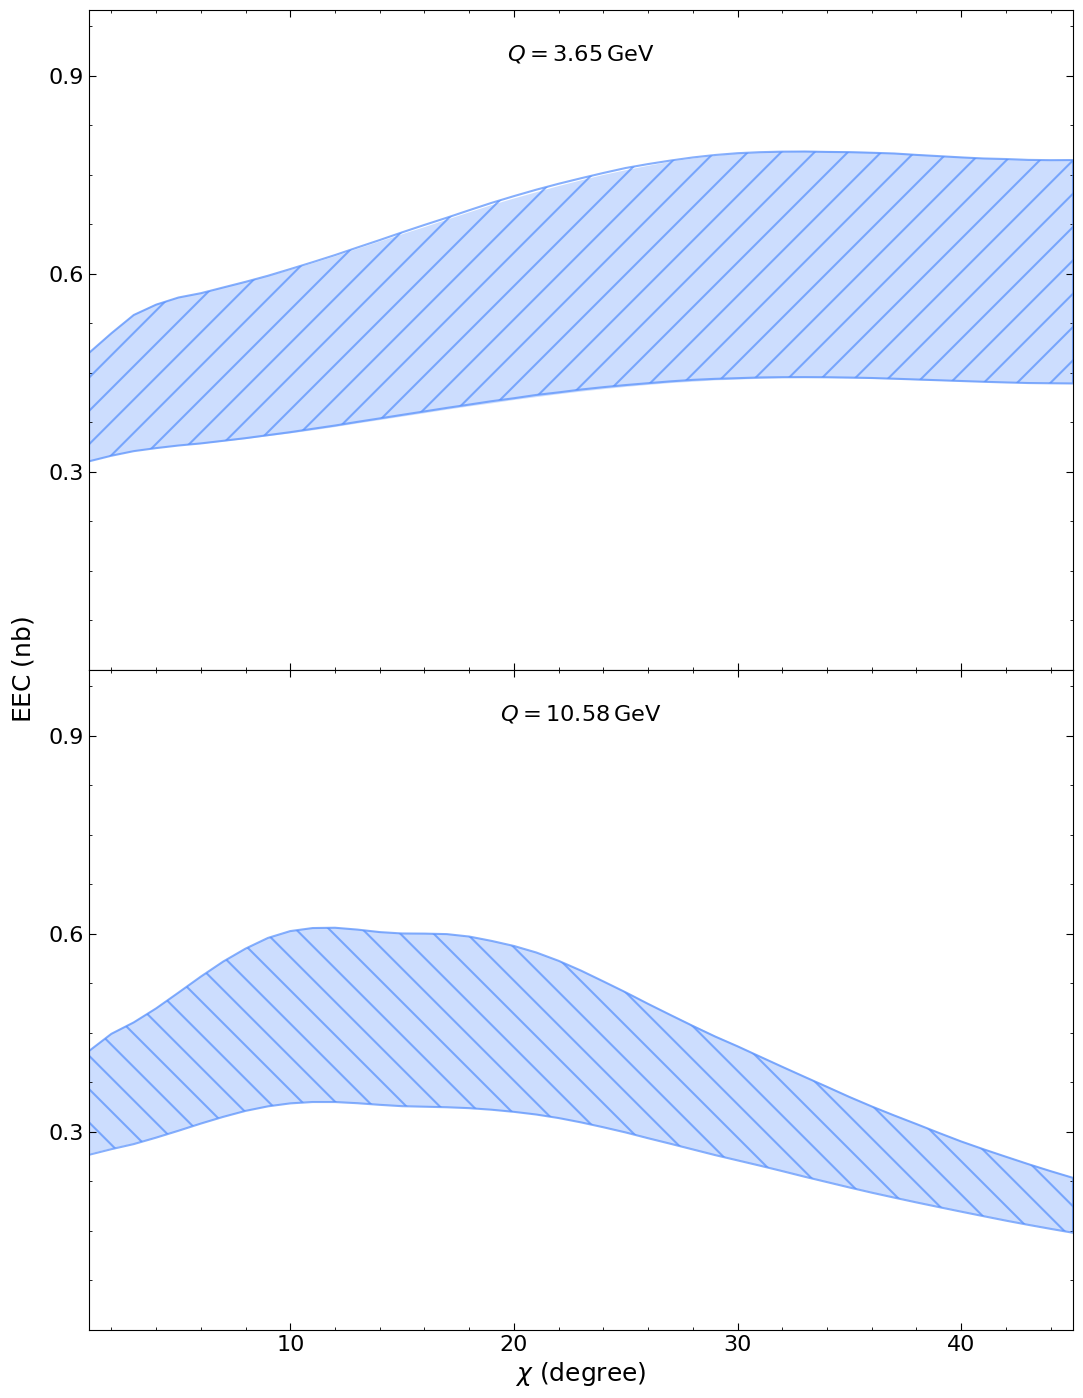

saved: Plot_Data/Figures/ee_eec_compare.pdf


In [7]:
_assert_same_scan(ee_eec_w, ee_eec_wo, label="EE EEC")

q_values = [float(value) for value in ee_eec_w["Q_list"]]

fig, axes = plt.subplots(
    len(q_values),
    1,
    figsize=ee_eec_figsize,
    sharex=True,
    sharey=False,
    gridspec_kw={"hspace": 0.0},
)
axes = np.atleast_1d(axes)

for ifig, (ax, Q) in enumerate(zip(axes, q_values)):
    entry_w = ee_eec_w["by_kinematics"][float(Q)]
    entry_wo = ee_eec_wo["by_kinematics"][float(Q)]
    chi_deg = _assert_same_chi(entry_w, entry_wo, label=f"EE EEC Q={Q:g}")

    lower_w = ee_eec_y_scale * np.asarray(entry_w["lower_68"], dtype=float)
    upper_w = ee_eec_y_scale * np.asarray(entry_w["upper_68"], dtype=float)
    lower_wo = ee_eec_y_scale * np.asarray(entry_wo["lower_68"], dtype=float)
    upper_wo = ee_eec_y_scale * np.asarray(entry_wo["upper_68"], dtype=float)

    _fill_band(ax, chi_deg, lower_wo, upper_wo, blue, branch_label=label_wo, zorder=1)
    _fill_band(ax, chi_deg, lower_w, upper_w, blue, branch_label=label_w, zorder=2, hatch_override=_w_hatch_for_q(Q, q_values))

    panel_key = round(float(Q), 2)
    panel_bounds = [lower_w, upper_w, lower_wo, upper_wo]

    _style_axis(ax)
    ax.set_xlim(*ee_eec_xlim)
    ax.set_xticks(shared_chi_xticks)
    _set_panel_ylim(ax, panel_bounds, manual_ylim=ee_eec_panel_ylims.get(panel_key), manual_yticks=ee_eec_panel_yticks.get(panel_key))
    y0, y1 = ax.get_ylim()
    note_idx = int(round((len(chi_deg) - 1) * ee_eec_scale_note_x_frac))
    note_x = chi_deg[note_idx]
    band_floor = np.minimum(lower_w, lower_wo)
    note_y = max(y0 + ee_eec_scale_note_gap_frac * (y1 - y0), band_floor[note_idx] - ee_eec_scale_note_gap_frac * (y1 - y0))
    ax.text(
        0.5,
        0.95,
        rf"$Q = {float(Q):g}\,\mathrm{{GeV}}$",
        transform=ax.transAxes,
        fontsize=0.90 * sizeOfFont,
        verticalalignment="top",
        horizontalalignment="center",
        bbox=props,
    )
    ax.text(note_x, note_y, ee_eec_scale_note, fontsize=0.92 * sizeOfFont, verticalalignment="top", horizontalalignment="right")
axes[0].tick_params(labelbottom=False)
axes[-1].set_xlabel(r"$\chi\ (\mathrm{degree})$", fontsize=sizeOfFont)
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.10, top=0.98, hspace=0.0)
divider_y = axes[0].get_position().y0 if len(axes) > 1 else 0.5 * (axes[0].get_position().y0 + axes[0].get_position().y1)
fig.text(ee_eec_ylabel_x, divider_y, ee_eec_ylabel, fontsize=sizeOfFont, rotation=90, verticalalignment="center", horizontalalignment="center")
plt.show()
_save_figure(fig, "ee_eec_compare")
